# The Time Diversification Effect

In [2]:
import pandas as pd
import numpy as np
import random
from matplotlib import pyplot as plt
import seaborn as sns
from datetime import date
from dateutil.relativedelta import relativedelta

from trading_algos import optimization as tao
from trading_algos import datasets as tad
from trading_algos import plots as tap
from trading_algos import utils as tau
from trading_algos.utils import head_tail as ht

%load_ext autoreload
%autoreload 2

2026-05-22 19:33:48.488 | INFO     | trading_algos.config:<module>:11 - PROJ_ROOT path is: /home/jamie/code/JamieW365/trading_algos


## Load Data

In [3]:
# Load a complete collection of S&P500 stocks from repository
# Not interested in survivors here
df_stocks = tad.get_sp500(survivors=False)

In [4]:
ht(df_stocks)

Price            Close                                                       \
Ticker               A         AA    AAL        AAP        AAPL        ABBV   
Date                                                                          
1962-01-02         NaN   1.473408    NaN        NaN         NaN         NaN   
1962-01-03         NaN   1.495946    NaN        NaN         NaN         NaN   
1962-01-04         NaN   1.495946    NaN        NaN         NaN         NaN   
2026-03-12  111.629997  65.930000  10.55  52.660000  255.759995  225.369995   
2026-03-13  111.510002  63.590000  10.30  51.730000  250.119995  219.679993   
2026-03-16  111.830002  66.599998  10.49  53.189999  252.820007  221.449997   

Price                                              ...    Volume             \
Ticker            ABNB ABS         ABT       ACGL  ...       XOM       XRAY   
Date                                               ...                        
1962-01-02         NaN NaN         NaN        NaN  ...    902400        NaN   
1962-01-03         NaN NaN         NaN        NaN  ...   1200000        NaN   
1962-01-04         NaN NaN         NaN        NaN  ...   1088000        NaN   
2026-03-12  127.699997 NaN  108.139999  94.220001  ...  26054000  4793400.0   
2026-03-13  126.300003 NaN  108.029999  93.470001  ...  22414100  5267000.0   
2026-03-16  128.320007 NaN  109.949997  93.699997  ...  14735861  3467391.0   

Price                                                                      \
Ticker          XRX        XYL        XYZ        YUM        ZBH      ZBRA   
Date                                                                        
1962-01-02    51233        NaN        NaN        NaN        NaN       NaN   
1962-01-03    51233        NaN        NaN        NaN        NaN       NaN   
1962-01-04   198099        NaN        NaN        NaN        NaN       NaN   
2026-03-12  2359700  1626400.0  8599800.0  1781000.0  3184500.0  849300.0   
2026-03-13  2888800  1842200.0  7134200.0  1119600.0  1818300.0  755500.0   
2026-03-16  3141624  1646872.0  6071738.0  2191490.0  1955785.0  577565.0   

Price                             
Ticker           ZION        ZTS  
Date                              
1962-01-02        NaN        NaN  
1962-01-03        NaN        NaN  
1962-01-04        NaN        NaN  
2026-03-12  1579700.0  3955100.0  
2026-03-13  1412900.0  3783200.0  
2026-03-16  1029592.0  3665230.0  

[6 rows x 3300 columns]

In [5]:
df_stocks.shape

(16158, 3300)

In [6]:
print(df_stocks.columns.get_level_values(1).nunique(), 'stocks')

660 stocks


## Simulating Portfolios

In [8]:
df_prices = df_stocks.Close
ht(df_prices)

Ticker,A,AA,AAL,AAP,AAPL,ABBV,ABNB,ABS,ABT,ACGL,...,XOM,XRAY,XRX,XYL,XYZ,YUM,ZBH,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,NaN,1.473408,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.088754,NaN,0.635471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-03,NaN,1.495946,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.090072,NaN,0.647386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-04,NaN,1.495946,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.090292,NaN,0.643414,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-12,111.629997,65.930000,10.55,52.660000,255.759995,225.369995,127.699997,NaN,108.139999,94.220001,...,153.529999,11.80,1.710000,120.019997,59.900002,158.460007,92.589996,204.050003,54.240002,115.459999
2026-03-13,111.510002,63.590000,10.30,51.730000,250.119995,219.679993,126.300003,NaN,108.029999,93.470001,...,156.119995,11.54,1.660000,119.879997,59.790001,160.399994,93.199997,202.720001,53.099998,115.620003
2026-03-16,111.830002,66.599998,10.49,53.189999,252.820007,221.449997,128.320007,NaN,109.949997,93.699997,...,157.229996,11.73,1.540000,121.070000,59.849998,161.779999,93.300003,203.970001,53.540001,118.150002


In [14]:
df_stocks.columns.get_level_values(1).unique()

Index(['A', 'AA', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABNB', 'ABS', 'ABT', 'ACGL',
       ...
       'XOM', 'XRAY', 'XRX', 'XYL', 'XYZ', 'YUM', 'ZBH', 'ZBRA', 'ZION',
       'ZTS'],
      dtype='object', name='Ticker', length=660)

In [9]:
years = np.arange(1,31)
years

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

In [54]:
1/12

0.08333333333333333

In [74]:
for i in range(12, 30*12+1, 3):
    print(i)

12
15
18
21
24
27
30
33
36
39
42
45
48
51
54
57
60
63
66
69
72
75
78
81
84
87
90
93
96
99
102
105
108
111
114
117
120
123
126
129
132
135
138
141
144
147
150
153
156
159
162
165
168
171
174
177
180
183
186
189
192
195
198
201
204
207
210
213
216
219
222
225
228
231
234
237
240
243
246
249
252
255
258
261
264
267
270
273
276
279
282
285
288
291
294
297
300
303
306
309
312
315
318
321
324
327
330
333
336
339
342
345
348
351
354
357
360


In [83]:
(((df_prices / df_prices.shift(252))**(1/(1))) - 1).std()

Ticker
A       0.357410
AA      0.459191
AAL     0.679498
AAP     0.339712
AAPL    0.614687
          ...   
YUM     0.244178
ZBH     0.253212
ZBRA    0.421346
ZION    0.366346
ZTS     0.230573
Length: 660, dtype: float64

In [ ]:
years_held = []
cagr = []
risk = []
ret = []
sharpe = []
act_growth = []

for y in range(1, 31):

    # 252 trading days in an average year
    trading_periods = y*252

    df_returns = (((df_prices / df_prices.shift(trading_periods))**(1/(y))) - 1)
    inv_cagr = df_returns.mean()
    cagr.append(inv_cagr)
    risk.append(df_returns.std())


In [81]:
len(risk)

660

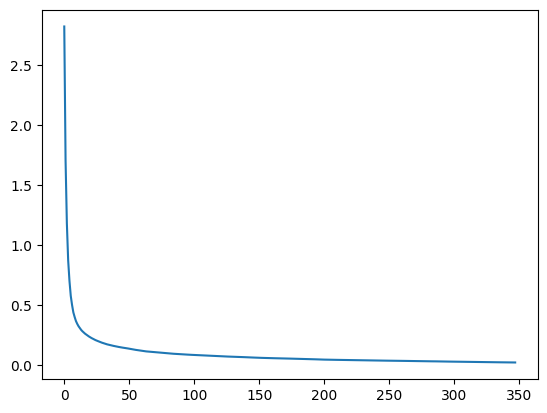

In [66]:
plt.plot(var[12:])

In [39]:
years = np.arange(1,31)
cagr = []

df_cagr = pd.DataFrame({'Years Held':years})

for y in years:
    
    trading_days = y*252

    # Compute rolling CAGR
    df_cagr.iloc[y-1] = cagr.append((((df_prices / df_prices.shift(trading_days))**(1/y)) - 1).mean().values.tolist())

In [40]:
df_cagr

,Years Held
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,NaN
7,NaN
8,NaN
9,NaN
